In [41]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
import math

In [42]:
img = cv2.imread("D:\Code\CDIO3\crop_plate.jpg")

In [43]:
# GAUSSIAN_SMOOTH_FILTER_SIZE = (5, 5) #kích cỡ càng to thì càng mờ
# ADAPTIVE_THRESH_BLOCK_SIZE = 19 
# ADAPTIVE_THRESH_WEIGHT = 9  

# ###################################################################################################
# def preprocess(imgOriginal):

#     imgGrayscale = extractValue(imgOriginal)
#     # imgGrayscale = cv2.cvtColor(imgOriginal,cv2.COLOR_BGR2GRAY) nên dùng hệ màu HSV
#     # Trả về giá trị cường độ sáng ==> ảnh gray
#     imgMaxContrastGrayscale = maximizeContrast(imgGrayscale) #để làm nổi bật biển số hơn, dễ tách khỏi nền
#     #cv2.imwrite("imgGrayscalePlusTopHatMinusBlackHat.jpg",imgMaxContrastGrayscale)
#     height, width = imgGrayscale.shape

#     imgBlurred = np.zeros((height, width, 1), np.uint8)
#     imgBlurred = cv2.GaussianBlur(imgMaxContrastGrayscale, GAUSSIAN_SMOOTH_FILTER_SIZE, 0)
#     #cv2.imwrite("gauss.jpg",imgBlurred)
#     #Làm mịn ảnh bằng bộ lọc Gauss 5x5, sigma = 0

#     imgThresh = cv2.adaptiveThreshold(imgBlurred, 255.0, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY_INV, ADAPTIVE_THRESH_BLOCK_SIZE, ADAPTIVE_THRESH_WEIGHT)

#     #Tạo ảnh nhị phân
#     return imgGrayscale, imgThresh
# #Trả về ảnh xám và ảnh nhị phân
# # end function

# ###################################################################################################
# def extractValue(imgOriginal):
#     height, width, numChannels = imgOriginal.shape
#     imgHSV = np.zeros((height, width, 3), np.uint8)
#     imgHSV = cv2.cvtColor(imgOriginal, cv2.COLOR_BGR2RGB)

#     imgHue, imgSaturation, imgValue = cv2.split(imgHSV)
    
#     #màu sắc, độ bão hòa, giá trị cường độ sáng
#     #Không chọn màu RBG vì vd ảnh màu đỏ sẽ còn lẫn các màu khác nữa nên khó xđ ra "một màu" 
#     return imgValue
# # end function

# ###################################################################################################
# def maximizeContrast(imgGrayscale):
#     #Làm cho độ tương phản lớn nhất 
#     height, width = imgGrayscale.shape
    
#     imgTopHat = np.zeros((height, width, 1), np.uint8)
#     imgBlackHat = np.zeros((height, width, 1), np.uint8)
#     structuringElement = cv2.getStructuringElement(cv2.MORPH_RECT, (3, 3)) #tạo bộ lọc kernel
    
#     imgTopHat = cv2.morphologyEx(imgGrayscale, cv2.MORPH_TOPHAT, structuringElement, iterations = 10) #nổi bật chi tiết sáng trong nền tối
#     #cv2.imwrite("tophat.jpg",imgTopHat)
#     imgBlackHat = cv2.morphologyEx(imgGrayscale, cv2.MORPH_BLACKHAT, structuringElement, iterations = 10) #Nổi bật chi tiết tối trong nền sáng
#     #cv2.imwrite("blackhat.jpg",imgBlackHat)
#     imgGrayscalePlusTopHat = cv2.add(imgGrayscale, imgTopHat) 
#     imgGrayscalePlusTopHatMinusBlackHat = cv2.subtract(imgGrayscalePlusTopHat, imgBlackHat)

#     #cv2.imshow("imgGrayscalePlusTopHatMinusBlackHat",imgGrayscalePlusTopHatMinusBlackHat)
#     #Kết quả cuối là ảnh đã tăng độ tương phản 
#     return imgGrayscalePlusTopHatMinusBlackHat
# imgGrayscaleplate, imgThreshplate = preprocess(img)
# canny_image = cv2.Canny(imgThreshplate, 250, 255)  # Canny Edge
# kernel = np.ones((5, 5), np.uint8)
# dilated_image = cv2.dilate(canny_image, kernel, iterations=1)  # Dilation
# cv2.imshow("dilated_image",dilated_image)
# ###### Draw contour and filter out the license plate  #############
# contours, hierarchy = cv2.findContours(dilated_image, cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)
# contours = sorted(contours, key=cv2.contourArea, reverse=True)[:10]

(199, 194)
(199, 194)


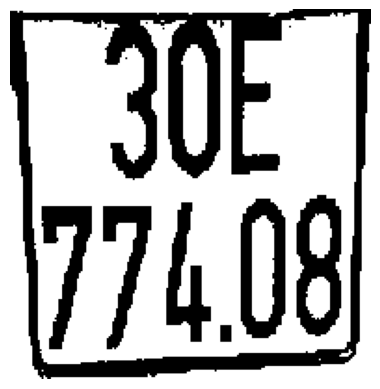

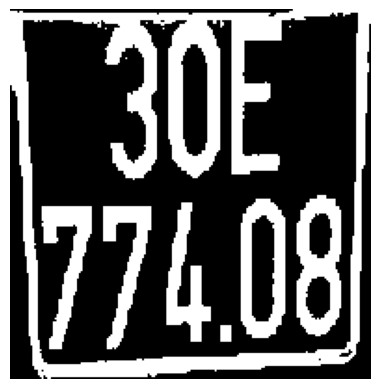

In [44]:

def grayimg(img):
    # Kiểm tra số chiều của ảnh
    if len(img.shape) == 2:
        return img

    B = img[:, :, 0]
    G = img[:, :, 1]
    R = img[:, :, 2]
    return (0.299*R + 0.587*G + 0.114*B).astype(np.uint8) 

gray = grayimg(img)
print(gray.shape)

def BinaryImg(img):
    for i in range(img.shape[0]):
        for j in range(img.shape[1]):
            if img[i, j] > 127:
                img[i, j] = 255
            else:
                img[i, j] = 0
    return img
binaryimg = BinaryImg(gray)
print(binaryimg.shape)
plt.imshow(gray, cmap='gray')
plt.axis('off')
plt.show()
plt.imshow(binaryimg, cmap='binary')
plt.axis('off')
plt.show()

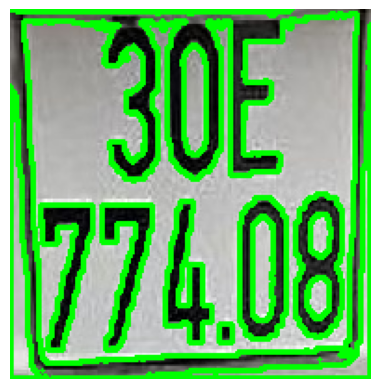

In [45]:

contours, hierarchy = cv2.findContours(binaryimg, cv2.RETR_TREE, cv2.CHAIN_APPROX_NONE)
img2 = img.copy()
cv2.drawContours(img2, contours, -1, (0, 255, 0), 2)
plt.imshow(cv2.cvtColor(img2, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.show()

In [46]:

def compute_rotation_angle(points):
    """
    PCA để tính góc nghiêng của tập điểm 2D
    points: mảng Nx2 hoặc list các cặp (x,y) như [[x1,y1], [x2,y2], ...]
    Trả về: góc xoay theo radian và độ
    """
    pts = np.array(points)

    # 1. Tính tọa độ trung bình
    pts = np.array(points, dtype=np.float32)
    mean = np.mean(pts, axis=0)
    centered = pts - mean

    # Covariance
    cov = np.cov(centered.T)
    eigenvalues, eigenvectors = np.linalg.eig(cov)

    idx = np.argmax(eigenvalues)
    principal_axis = eigenvectors[:, idx]

    angle_rad = np.arctan2(principal_axis[1], principal_axis[0])
    angle_deg = np.degrees(angle_rad)

    return angle_rad, angle_deg


In [47]:
def rotate_manual(img, angle):
    angle = np.deg2rad(angle)
    
    cosA = np.cos(angle)
    sinA = np.sin(angle)

    R = np.array([[cosA, -sinA],
                  [sinA,  cosA]])

    h, w = img.shape[:2]
    rotated = np.zeros_like(img)

    cx, cy = w//2, h//2

    for y in range(h):
        for x in range(w):
            # dịch về tâm
            xt = x - cx
            yt = y - cy
            
            # áp dụng ma trận
            xr, yr = R @ np.array([xt, yt])
            
            # đưa về tọa độ ảnh
            xr = int(xr + cx)
            yr = int(yr + cy)

            if 0 <= xr < w and 0 <= yr < h:
                rotated[yr, xr] = img[y, x]

    return rotated
# cnt = max(contours, key=cv2.contourArea).reshape(-1, 2)
# rad, deg = compute_rotation_angle(cnt)
# print("Góc nghiêng (rad):", rad)
# print("Góc nghiêng (deg):", deg)
# rotated_plate = rotate_manual(dilated_image, -rad)
# plt.imshow(cv2.cvtColor(rotated_plate, cv2.COLOR_BGR2RGB))
# plt.axis('off')
# plt.show()
# img3 = BinaryImg(grayimg(rotated_plate))
# plt.imshow(cv2.cvtColor(img3, cv2.COLOR_BGR2RGB))
# plt.axis('off')
# plt.show()


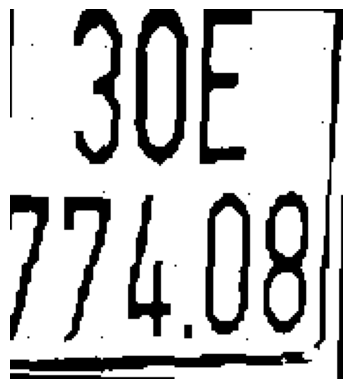

In [ ]:

def locate_license_plate(img, contours):
    screenCnt = None
    plate_img = None
    
    # Sắp xếp contour theo diện tích giảm dần để tìm cái to trước
    contours = sorted(contours, key=cv2.contourArea, reverse=True)[:10]

    for c in contours:
        # 1. Xấp xỉ đa giác
        peri = cv2.arcLength(c, True)
        approx = cv2.approxPolyDP(c, 0.05 * peri, True)
        # Chỉ lấy đa giác có 4 đỉnh
        if len(approx) == 4:
            (x, y, w, h) = cv2.boundingRect(approx)
            # 2. Tính toán tỉ lệ và diện tích
            ratio = w / h
            area = w * h
            # Biển vuông VN: ~1.4 | Biển dài VN: ~4.2
            check_vuong = 0.8 <= ratio <= 2
            check_dai = 2.5 <= ratio <= 7.0
            check_area = area > 2000 # Diện tích tối thiểu
            
            if check_area and (check_vuong or check_dai):
                screenCnt = approx
                
                # 3. Cắt ảnh biển số
                plate_img = img[y:y+h, x:x+w]
                
                break

    return screenCnt, plate_img
cnt = max(contours, key=cv2.contourArea).reshape(-1, 2)
rad, deg = compute_rotation_angle(cnt)
# screenCnt, plate_img = locate_license_plate(BinaryImg(grayimg(img2)), contours)
# plate_img = rotate_manual(plate_img, -rad)
# if plate_img is not None:
#     plt.imshow(cv2.cvtColor(plate_img, cv2.COLOR_BGR2RGB))
#     plt.axis('off')
#     plt.show()
# else: print(None)
def padding_img(img, kernel_size):
    """
    Thêm viền (padding) cho ảnh để khi trượt kernel không bị lỗi biên.
    """
    pad_h = kernel_size[0] // 2
    pad_w = kernel_size[1] // 2
    # Thêm viền giá trị 0 bao quanh ảnh
    padded_img = np.pad(img, ((pad_h, pad_h), (pad_w, pad_w)), mode='constant', constant_values=0)
    return padded_img

def manual_erosion(img, kernel_size=(3, 3)):
    """
    Thuật toán Co (Erosion):
    Di chuyển kernel qua từng pixel. 
    Nếu TẤT CẢ pixel dưới kernel là 255 (trắng) -> Giữ lại 255.
    Ngược lại (có ít nhất 1 điểm đen) -> Gán thành 0 (đen).
    => Tương đương phép toán AND hoặc lấy MIN.
    """
    H, W = img.shape
    k_h, k_w = kernel_size
    
    # Tạo ảnh output đen xì
    output = np.zeros((H, W), dtype=np.uint8)
    
    # Thêm padding
    padded_img = padding_img(img, kernel_size)
    
    # Duyệt qua từng pixel (Cửa sổ trượt)
    for i in range(H):
        for j in range(W):
            # Cắt vùng ảnh (Region of Interest) bằng kích thước kernel
            region = padded_img[i : i + k_h, j : j + k_w]
            
            # Logic EROSION: Lấy giá trị NHỎ NHẤT trong vùng
            # Nếu trong vùng có điểm đen (0), min sẽ là 0 -> Ăn mòn
            min_val = np.min(region)
            output[i, j] = min_val
            
    return output
def manual_dilation(img, kernel_size=(3, 3)):
    """
    Thuật toán Giãn (Dilation):
    Di chuyển kernel qua từng pixel.
    Nếu CÓ ÍT NHẤT 1 pixel dưới kernel là 255 (trắng) -> Gán thành 255.
    => Tương đương phép toán OR hoặc lấy MAX.
    """
    H, W = img.shape
    k_h, k_w = kernel_size
    
    output = np.zeros((H, W), dtype=np.uint8)
    padded_img = padding_img(img, kernel_size)
    
    for i in range(H):
        for j in range(W):
            region = padded_img[i : i + k_h, j : j + k_w]
            
            # Logic DILATION: Lấy giá trị LỚN NHẤT trong vùng
            # Chỉ cần 1 điểm trắng (255), max sẽ là 255 -> Phình to
            max_val = np.max(region)
            output[i, j] = max_val
            
    return output

# tempimg = plate_img.copy()

plt.imshow(cv2.cvtColor(tempimg, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.show()

In [49]:
img = tempimg.copy()

# Đảm bảo đúng nhị phân
_, bin_img = cv2.threshold(img, 127, 255, cv2.THRESH_BINARY)

orig = cv2.cvtColor(bin_img, cv2.COLOR_GRAY2BGR)

# ===== 2. Làm mượt để liền khối =====
kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (5,5))
close = cv2.morphologyEx(bin_img, cv2.MORPH_CLOSE, kernel, iterations=2)

# ===== 3. Tìm contour =====
contours, _ = cv2.findContours(close, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
contours = sorted(contours, key=cv2.contourArea, reverse=True)

plate_cnt = None
for cnt in contours:
    peri = cv2.arcLength(cnt, True)
    approx = cv2.approxPolyDP(cnt, 0.02 * peri, True)
    if len(approx) == 4:
        plate_cnt = approx
        break

if plate_cnt is None:
    print("❌ Không tìm được biển")
    exit()

# ===== 4. Sắp xếp 4 góc =====
def order_points(pts):
    rect = np.zeros((4,2), dtype="float32")
    s = pts.sum(axis=1)
    rect[0] = pts[np.argmin(s)]
    rect[2] = pts[np.argmax(s)]
    diff = np.diff(pts, axis=1)
    rect[1] = pts[np.argmin(diff)]
    rect[3] = pts[np.argmax(diff)]
    return rect

rect = order_points(plate_cnt.reshape(4,2))

# ===== 5. Tính kích thước =====
(tl, tr, br, bl) = rect
w = int(max(np.linalg.norm(br-bl), np.linalg.norm(tr-tl)))
h = int(max(np.linalg.norm(tr-br), np.linalg.norm(tl-bl)))

dst = np.array([[0,0],[w-1,0],[w-1,h-1],[0,h-1]], dtype="float32")

# ===== 6. Warp =====
M = cv2.getPerspectiveTransform(rect, dst)
warped = cv2.warpPerspective(bin_img, M, (w, h))

# ===== 7. Lưu & hiển thị =====
cv2.imshow("Binary", bin_img)
cv2.imshow("Warped", warped)

cv2.imwrite("plate_fixed.png", warped)
cv2.waitKey(0)
cv2.destroyAllWindows()

In [50]:
# import cv2
# import numpy as np
# import matplotlib.pyplot as plt
# from sklearn.decomposition import PCA

# # --- 1. TẠO DỮ LIỆU CỰC ĐOAN (Nghiêng 45 độ) ---
# h, w = 300, 300
# img = np.zeros((h, w), dtype=np.uint8)

# # Tạo chữ ở giữa
# font = cv2.FONT_HERSHEY_SIMPLEX
# img_temp = np.zeros((h, w), dtype=np.uint8)
# # Viết chữ to và dài để dễ nhìn trục
# cv2.putText(img_temp, '## HELLO PCA ##', (20, 160), font, 1, (255), 4)

# # Xoay nghiêng 45 độ ngược chiều kim đồng hồ
# center = (w // 2, h // 2)
# M = cv2.getRotationMatrix2D(center, 45, 1) 
# img_rotated = cv2.warpAffine(img_temp, M, (w, h))

# # --- 2. LẤY DỮ LIỆU ---
# y_coords, x_coords = np.where(img_rotated > 0)
# data = np.column_stack((x_coords, y_coords))

# # --- 3. PCA TÍNH TOÁN ---
# pca = PCA(n_components=2)
# pca.fit(data)

# # Lấy vector trục chính (PC1)
# v = pca.components_[0]
# # Tính góc bằng Radian
# angle_rad = np.arctan2(v[1], v[0])

# # --- 4. XOAY PHẲNG LẠI (DESKEW) ---
# # Ma trận xoay ngược lại góc đã tìm thấy
# c, s = np.cos(-angle_rad), np.sin(-angle_rad)
# rotation_matrix = np.array(((c, -s), (s, c)))

# # Đưa về gốc (0,0) rồi xoay
# data_centered = data - pca.mean_
# # ... (Đoạn code trước đó giữ nguyên)
# data_rotated = np.dot(data_centered, rotation_matrix)

# # === BƯỚC BỔ SUNG: KIỂM TRA DỌC HAY NGANG ===
# # Tính kích thước bao quanh đám mây điểm
# min_x, max_x = np.min(data_rotated[:, 0]), np.max(data_rotated[:, 0])
# min_y, max_y = np.min(data_rotated[:, 1]), np.max(data_rotated[:, 1])

# curr_width = max_x - min_x
# curr_height = max_y - min_y

# print(f"Kích thước sau khi PCA: Rộng={curr_width:.2f}, Cao={curr_height:.2f}")

# # Nếu Chiều cao lớn hơn Chiều rộng -> Nó đang đứng -> Cần xoay 90 độ
# if curr_height > curr_width:
#     print("Phát hiện biển số đang dựng đứng -> Đang xoay lại 90 độ...")
#     # Ma trận xoay 90 độ
#     theta_90 = np.radians(90)
#     c90, s90 = np.cos(theta_90), np.sin(theta_90)
#     rot_90 = np.array(((c90, -s90), (s90, c90)))
    
#     # Xoay tiếp
#     data_rotated = np.dot(data_rotated, rot_90)

# # ... (Tiếp tục đoạn code vẽ đồ thị bên dưới)

# # --- 5. VẼ SO SÁNH TRỰC QUAN ---
# fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))

# # TẠO MÀU SẮC: Tô màu dựa trên vị trí của điểm trong chuỗi ký tự
# # Điểm nào viết trước có màu khác, viết sau có màu khác
# colors = range(len(data)) 

# # === HÌNH 1: TRƯỚC KHI XOAY ===
# ax1.scatter(data[:, 0], data[:, 1], c=colors, cmap='jet', s=5, alpha=0.5)
# ax1.set_title("1. Dữ liệu gốc (Nghiêng 45 độ)")
# ax1.set_xlim(-150, 150); ax1.set_ylim(150, -150) # Đặt tâm ở (0,0)
# ax1.grid(True)
# ax1.set_xlim(0, 300); ax1.set_ylim(300, 0) # Đảo trục Y cho đúng mắt nhìn

# # Vẽ mũi tên Vector PCA tìm được (Mũi tên chỉ hướng xoay)
# mean_x, mean_y = pca.mean_
# scale = 100 # Độ dài mũi tên
# ax1.arrow(mean_x, mean_y, v[0]*scale, v[1]*scale, 
#           color='black', width=3, head_width=10, label='Trục PCA tìm thấy')
# ax1.legend()


# # === HÌNH 2: SAU KHI PCA CHỈNH LẠI ===
# ax2.scatter(data_rotated[:, 0], data_rotated[:, 1], c=colors, cmap='jet', s=5, alpha=0.5)
# ax2.set_title("Kết quả")
# ax2.set_xlim(-150, 150); ax2.set_ylim(150, -150) # Đặt tâm ở (0,0)
# ax2.grid(True)

# # Vẽ đường chân trời để so sánh
# ax2.axhline(0, color='black', linewidth=2, linestyle='--')

# plt.tight_layout()
# plt.show()

# print(f"PCA phát hiện góc nghiêng là: {np.degrees(angle_rad):.2f} độ")
# print("Đã xoay ngược lại để dải màu nằm song song với mặt đất.")

--- LỌC CONTOUR (29 contour tìm thấy) ---


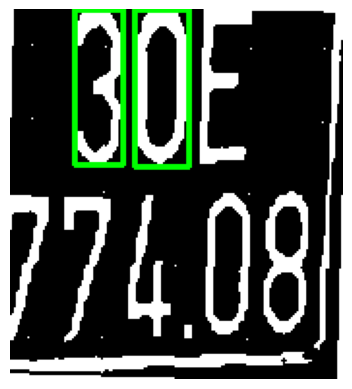

(191, 172)
[(64, 0, 28, 81), (33, 0, 25, 80)]


In [51]:


def find_character_contours_heuristic(image):
    # 1. Tiền xử lý (Gray -> Binary -> Invert nếu cần)
    if len(image.shape) == 3:
        gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    else:
        gray = image.copy()
        
    # Dùng Otsu để tách nền tốt nhất
    _, binary = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

    # Đảo màu nếu nền trắng (để tìm contour vật thể màu trắng)
    if np.sum(binary == 255) > np.sum(binary == 0):
        binary = cv2.bitwise_not(binary)

    # 2. Tìm Contour
    contours, _ = cv2.findContours(binary, cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)
    
    # Tính diện tích toàn biển số để làm chuẩn
    plate_h, plate_w = binary.shape
    plate_area = plate_h * plate_w
    
    valid_chars = []
    candidates = []

    print(f"--- LỌC CONTOUR ({len(contours)} contour tìm thấy) ---")
    
    for c in contours:
        (x, y, w, h) = cv2.boundingRect(c)
        
        # --- CÁC ĐẶC ĐIỂM HÌNH HỌC ---
        cnt_area = w * h
        ratio = w / h               # Tỷ lệ Rộng / Cao
        area_ratio = cnt_area / plate_area # Diện tích contour / Diện tích biển
        height_ratio = h / plate_h  # Chiều cao contour / Chiều cao biển

        # --- ÁP DỤNG LUẬT LỌC (HEURISTIC RULES) ---
        
        # 1. Diện tích: Ký tự phải chiếm từ 0.5% đến 15% diện tích biển
        # (Loại bỏ nhiễu chấm nhỏ và khung viền quá to)
        check_area = 0.005 < area_ratio < 0.15
        
        # 2. Tỷ lệ W/H: Ký tự thường cao hơn rộng (ratio < 1). 
        # Tuy nhiên số 4, 3, M có thể gần vuông. Số 1 rất hẹp.
        # Khoảng an toàn: 0.15 (số 1) đến 1.0 (số vuông).
        check_ratio = 0.15 < ratio < 1.0
        
        # 3. Chiều cao: Ký tự phải cao ít nhất 40% chiều cao biển số
        # (Loại bỏ các vạch kẻ ngang, đinh ốc nằm ở rìa)
        check_height = 0.4 < height_ratio < 0.95

        # In ra để debug nếu cần
        # print(f"Cnt: Area={area_ratio:.3f}, Ratio={ratio:.2f}, H_Ratio={height_ratio:.2f} -> {check_area and check_ratio and check_height}")

        if check_area and check_ratio and check_height:
            candidates.append((x, y, w, h))

    # --- LOẠI BỎ KHUNG LỒNG NHAU (Fix lỗi số 6, 8, 0, 4) ---
    valid_chars = remove_inner_boxes(candidates)

    # Vẽ kết quả kiểm tra
    debug_img = cv2.cvtColor(binary, cv2.COLOR_GRAY2BGR)
    for (x, y, w, h) in valid_chars:
        cv2.rectangle(debug_img, (x, y), (x + w, y + h), (0, 255, 0), 2)
    
    plt.imshow(debug_img)
    plt.axis('off')
    plt.show()

    return valid_chars

# Hàm phụ: Loại bỏ khung lồng nhau (Copy lại để dùng)
def remove_inner_boxes(boxes):
    if not boxes: return []
    keep = [True] * len(boxes)
    for i in range(len(boxes)):
        for j in range(len(boxes)):
            if i == j: continue
            (xi, yi, wi, hi) = boxes[i]
            (xj, yj, wj, hj) = boxes[j]
            # Nếu i nằm trọn trong j -> Xóa i
            if xi >= xj and yi >= yj and (xi+wi) <= (xj+wj) and (yi+hi) <= (yj+hj):
                keep[i] = False
                break
    return [boxes[i] for i in range(len(boxes)) if keep[i]]
# Gọi hàm
result = find_character_contours_heuristic(plate_img)
print(plate_img.shape)
print(result)

In [52]:
# import cv2
# import numpy as np
# import matplotlib.pyplot as plt

# def visualize_inner_contours():
#     # 1. TẠO ẢNH GIẢ LẬP (Nền đen - Chữ trắng)
#     # Kích thước 300x200
#     img = np.zeros((200, 300), dtype=np.uint8)
    
#     # Viết chữ "8" và "A" (những chữ có lỗ hổng)
#     font = cv2.FONT_HERSHEY_SIMPLEX
#     cv2.putText(img, '8', (50, 150), font, 5, (255), 10, cv2.LINE_AA)
#     cv2.putText(img, 'A', (180, 150), font, 5, (255), 10, cv2.LINE_AA)

#     # 2. TÌM CONTOURS
#     # cv2.RETR_TREE: Quan trọng nhất! Nó lấy cả viền ngoài lẫn viền trong (lỗ hổng)
#     contours, hierarchy = cv2.findContours(img, cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)

#     print(f"Tổng số đường bao tìm thấy: {len(contours)}")
    
#     # 3. VẼ ĐỂ MINH HỌA
#     # Chuyển sang ảnh màu để vẽ được màu xanh/đỏ
#     img_display = cv2.cvtColor(img, cv2.COLOR_GRAY2BGR)

#     # hierarchy có dạng: [Next, Previous, First_Child, Parent]
#     # hierarchy[0] chứa thông tin của tất cả contour
    
#     for i, c in enumerate(contours):
#         # Lấy thông tin gia phả
#         # hierarchy[0][i][3] là Parent. Nếu = -1 nghĩa là không có cha (nó là viền ngoài)
#         parent_index = hierarchy[0][i][3]
        
#         if parent_index == -1:
#             # Đây là VIỀN NGOÀI (Outer Contour) -> Vẽ màu XANH LÁ
#             color = (0, 255, 0)
#             cv2.drawContours(img_display, contours, i, color, 3)
#             # Ghi chú thích
#             x, y = c[0][0]
#             cv2.putText(img_display, "Outer", (x, y-10), cv2.FONT_HERSHEY_SIMPLEX, 0.5, color, 1)
#         else:
#             # Đây là LỖ HỔNG BÊN TRONG (Inner Contour) -> Vẽ màu ĐỎ
#             color = (255, 0, 0) # Màu đỏ (RGB cho matplotlib) hoặc BGR cho OpenCV
#             cv2.drawContours(img_display, contours, i, (0, 0, 255), 3) # Vẽ đỏ (BGR)
#             # Ghi chú thích
#             x, y = c[0][0]
#             cv2.putText(img_display, "Hole", (x, y+40), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 0, 255), 1)

#     # 4. HIỂN THỊ
#     plt.figure(figsize=(10, 6))
#     plt.imshow(cv2.cvtColor(img_display, cv2.COLOR_BGR2RGB))
#     plt.title("Minh hoa Contour ngoai (Xanh) va Contour lo hong (Do)")
#     plt.axis('off')
#     plt.show()

# if __name__ == "__main__":
#     visualize_inner_contours()

In [53]:
import os
import time

# # --- 1. CẤU HÌNH ---
# DATASET_DIR = "my_dataset"  # Thư mục sẽ lưu data
# TARGET_SIZE = 28            # Kích thước ảnh muốn train (28x28 là chuẩn)

# # Tạo thư mục gốc nếu chưa có
# if not os.path.exists(DATASET_DIR):
#     os.makedirs(DATASET_DIR)
    
def sort_rects_direct(rects):
    """
    Input: list các tuple [(x, y, w, h), ...]
    Output: list đã sắp xếp theo dòng (trên->dưới) và cột (trái->phải)
    """
    if len(rects) == 0: return []
    
    # Bước 1: Sắp xếp sơ bộ theo Y (để biết cái nào nằm trên, cái nào nằm dưới)
    rects = sorted(rects, key=lambda r: r[1])
    
    # Bước 2: Phân dòng
    # Tính chiều cao trung bình để làm ngưỡng phân tách dòng
    mean_h = np.mean([r[3] for r in rects])
    
    lines = []
    current_line = [rects[0]]
    
    for i in range(1, len(rects)):
        curr_rect = rects[i]
        prev_rect = rects[i-1]
        
        # Nếu y của ký tự hiện tại lệch quá nhiều so với ký tự trước -> Sang dòng mới
        # (Ngưỡng lệch là 1/2 chiều cao trung bình)
        if abs(curr_rect[1] - prev_rect[1]) > mean_h * 0.5:
            # Hết dòng cũ -> Sort dòng cũ từ Trái qua Phải (theo x)
            lines.append(sorted(current_line, key=lambda r: r[0]))
            # Bắt đầu dòng mới
            current_line = [curr_rect]
        else:
            # Vẫn cùng dòng
            current_line.append(curr_rect)
            
    # Đừng quên dòng cuối cùng
    lines.append(sorted(current_line, key=lambda r: r[0]))
    
    # Bước 3: Nối các dòng lại thành 1 list duy nhất
    final_sorted = [r for line in lines for r in line]
    return final_sorted
# # Hàm chuẩn hóa (Dùng hàm xịn Zoom-to-fit tôi đưa lúc nãy)
def process_char_standardized(binary_img, x, y, w, h, target_size=28, padding=2):
    roi = binary_img[y:y+h, x:x+w]
    if roi.size == 0: return None
  
    # --- FIX LOGIC ĐẢO MÀU (DÙNG 4 GÓC THAY VÌ 50% PIXEL) ---
    roi_h, roi_w = roi.shape
    
    # Lấy giá trị màu tại 4 góc (0: Đen, 255: Trắng)
    # Góc trên-trái, trên-phải, dưới-trái, dưới-phải
    corners = [
        roi[0, 0], 
        roi[0, roi_w-1], 
        roi[roi_h-1, 0], 
        roi[roi_h-1, roi_w-1]
    ]
    
    # Đếm xem bao nhiêu góc là màu trắng (> 127)
    white_corners = sum(1 for c in corners if c > 127)
    
    # Nếu 3/4 góc trở lên là trắng -> Chắc chắn là NỀN TRẮNG -> Đảo màu
    if white_corners >= 3:
        roi = cv2.bitwise_not(roi)
    # --------------------------------------------------------

    # Tính toán Scale để Zoom-to-fit (Giữ nguyên tỉ lệ)
    max_dim_size = target_size - (2 * padding)
    scale = max_dim_size / max(roi_h, roi_w)
    
    new_w = int(roi_w * scale)
    new_h = int(roi_h * scale)
    
    if scale > 1:
        resized_roi = cv2.resize(roi, (new_w, new_h), interpolation=cv2.INTER_CUBIC)
    else:
        resized_roi = cv2.resize(roi, (new_w, new_h), interpolation=cv2.INTER_AREA)
        
    # Tạo canvas màu đen
    canvas = np.zeros((target_size, target_size), dtype=np.uint8)
    
    x_center = (target_size - new_w) // 2
    y_center = (target_size - new_h) // 2
    
    # Dán ROI vào giữa canvas
    canvas[y_center:y_center+new_h, x_center:x_center+new_w] = resized_roi
    
    return canvas

# def labeling_tool(plate_img, sorted_rects):
#     """
#     Chạy tool gán nhãn thủ công
#     """
#     # Xử lý ảnh đầu vào
#     if len(plate_img.shape) == 3:
#         gray = cv2.cvtColor(plate_img, cv2.COLOR_BGR2GRAY)
#     else:
#         gray = plate_img.copy()
        
#     _, bin_plate = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
#     if np.sum(bin_plate == 255) > np.sum(bin_plate == 0): bin_plate = cv2.bitwise_not(bin_plate)

#     print("--- HƯỚNG DẪN SỬ DỤNG ---")
#     print(" Nhập ký tự (0-9, A-Z) để lưu.")
#     print(" Nhấn SPACE (Dấu cách) để BỎ QUA (nếu là rác/nhiễu).")
#     print(" Nhấn ESC để THOÁT chương trình.")
#     print("-------------------------")

#     for i, (x, y, w, h) in enumerate(sorted_rects):
#         # 1. Chuẩn bị ảnh để lưu (Size nhỏ 28x28)
#         char_to_save = process_char_standardized(bin_plate, x, y, w, h, target_size=TARGET_SIZE, padding=3)
#         if char_to_save is None: continue

#         # 2. Chuẩn bị ảnh để HIỂN THỊ CHO ÔNG NHÌN (Phóng to lên 10 lần)
#         display_img = cv2.resize(char_to_save, (280, 280), interpolation=cv2.INTER_NEAREST)
        
#         # 3. Vẽ khung chữ nhật trên ảnh gốc để ông biết đang làm chữ nào
#         debug_plate = plate_img.copy()
#         cv2.rectangle(debug_plate, (x, y), (x + w, y + h), (0, 255, 0), 2)
        
#         # 4. Hiển thị 2 cửa sổ
#         cv2.imshow("1. Vi tri tren bien so", debug_plate)
#         cv2.imshow("2. Nhap ky tu nay (SPACE de bo qua)", display_img)
        
#         # Di chuyển cửa sổ cho dễ nhìn
#         cv2.moveWindow("1. Vi tri tren bien so", 0, 0)
#         cv2.moveWindow("2. Nhap ky tu nay (SPACE de bo qua)", 400, 0)

#         # 5. Đợi nhập phím
#         while True:
#             key = cv2.waitKey(0)
            
#             # Nếu nhấn ESC (27) -> Thoát hết
#             if key == 27:
#                 print("Đã thoát tool.")
#                 cv2.destroyAllWindows()
#                 return

#             # Nếu nhấn SPACE (32) -> Bỏ qua
#             if key == 32:
#                 print(">> Bỏ qua (Nhiễu)")
#                 break # Break while, sang vòng lặp for tiếp theo
                
#             # Xử lý ký tự nhập vào
#             char = chr(key).upper() # Chuyển về chữ hoa
            
#             # Kiểm tra xem có phải chữ/số hợp lệ không (0-9, A-Z)
#             if (char >= '0' and char <= '9') or (char >= 'A' and char <= 'Z'):
#                 # Tạo đường dẫn lưu
#                 class_dir = os.path.join(DATASET_DIR, char)
#                 if not os.path.exists(class_dir):
#                     os.makedirs(class_dir)
                
#                 # Tên file không trùng: timestamp + index
#                 timestamp = int(time.time() * 1000)
#                 filename = f"{timestamp}_{i}.jpg"
#                 save_path = os.path.join(class_dir, filename)
                
#                 # Lưu cái ảnh chuẩn hóa (28x28)
#                 cv2.imwrite(save_path, char_to_save)
#                 print(f" Đã lưu vào folder: {char}")
#                 break # Break while, sang chữ tiếp theo
#             else:
#                 print(" Phím không hợp lệ! Vui lòng nhập 0-9 hoặc A-Z")
#                 # Không break, lặp lại while để nhập lại

#     cv2.destroyAllWindows()
#     print(" Đã xử lý xong biển số này!")

# # --- GỌI HÀM ---
# # Lưu ý: sorted_rects là danh sách ông đã tìm và sort ở các bước trước
# sorted_rects = sort_rects_direct(find_character_contours_heuristic(plate_img))

# if 'sorted_rects' in globals() and len(sorted_rects) > 0:
#     labeling_tool(plate_img, sorted_rects)
# else:
#     print(" Chưa có biến sorted_rects. Hãy chạy phần tìm contour trước!")

In [54]:

# import os

# folder_path = "images"

# # Duyệt qua tất cả file trong folder
# for filename in os.listdir(folder_path):
#     # Kiểm tra đuôi file để tránh đọc nhầm file rác
#     if filename.endswith((".jpg", ".png", ".jpeg")):
#         # Nối đường dẫn: raw_plates + / + abc.jpg
#         full_path = os.path.join(folder_path, filename)
#     img_check = cv2.imread(full_path)
#     contours, hierarchy = cv2.findContours(BinaryImg(grayimg(img_check)), cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)
#     print(f"Số lượng đường viền tìm thấy: {len(contours)}")
#     # Hiển thị bằng matplotlib
#     plt.imshow(cv2.drawContours(img_check.copy(), contours, -1, (0, 255, 0), 2))
#     plt.axis('off')
#     plt.show()
#     screenCnt2, plate_img2 = locate_license_plate(BinaryImg(grayimg(img_check)), contours)
#     if(plate_img2 is None):
#         print("Không tìm thấy biển số trong ảnh:", filename)
#         continue
#     plate_img2 = rotate_manual(plate_img2, -rad)
#     if plate_img2 is not None:
#         plt.imshow(cv2.cvtColor(plate_img2, cv2.COLOR_BGR2RGB))
#         plt.axis('off')
#         plt.show()
#     else: print(None)
#     sorted_rects2 = sort_rects_direct(find_character_contours_heuristic(plate_img2))

#     if 'sorted_rects2' in globals() and len(sorted_rects2) > 0:
#         labeling_tool(plate_img2, sorted_rects2)
#     else:
#         print(" Chưa có biến sorted_rects. Hãy chạy phần tìm contour trước!")

In [55]:
# import os
# import cv2
# import numpy as np
# import joblib
# from sklearn.ensemble import RandomForestClassifier
# from sklearn.model_selection import train_test_split
# from sklearn.metrics import accuracy_score, classification_report
# import matplotlib.pyplot as plt

# # --- CẤU HÌNH ---
# DATASET_DIR = "my_dataset"   # Thư mục chứa dữ liệu đã gán nhãn
# MODEL_PATH = "rf_chars.joblib" # Tên file model sẽ lưu
# IMG_SIZE = 28                # Kích thước ảnh 28x28

# def load_dataset(data_path):
#     print(" Đang tải dữ liệu...")
#     data = []
#     labels = []
    
#     # Duyệt qua các folder con (0-9, A-Z)
#     if not os.path.exists(data_path):
#         print(f" Lỗi: Không tìm thấy thư mục {data_path}")
#         return [], []

#     classes = os.listdir(data_path)
    
#     total_files = 0
#     for label in classes:
#         class_dir = os.path.join(data_path, label)
#         if not os.path.isdir(class_dir): continue
        
#         # Đọc từng ảnh trong folder
#         for filename in os.listdir(class_dir):
#             img_path = os.path.join(class_dir, filename)
            
#             # Đọc ảnh grayscale
#             img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
            
#             if img is None: continue
            
#             # 1. Resize về đúng chuẩn (Safety check)
#             if img.shape != (IMG_SIZE, IMG_SIZE):
#                 img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
            
#             # 2. Flatten: Duỗi ảnh 28x28 thành 1 dòng 784 số
#             # Chia 255.0 để chuẩn hóa về dạng 0-1 (giúp model học tốt hơn)
#             flat_img = img.reshape(-1) / 255.0
            
#             data.append(flat_img)
#             labels.append(label)
#             total_files += 1

#     print(f" Đã tải xong {total_files} ảnh từ {len(classes)} lớp ký tự.")
#     return np.array(data), np.array(labels)

# # --- BẮT ĐẦU CHƯƠNG TRÌNH ---

# # 1. Load Data
# X, y = load_dataset(DATASET_DIR)

# if len(X) == 0:
#     print(" Không có dữ liệu để train! Hãy chạy tool labeling trước.")
#     exit()

# # 2. Mã hóa nhãn (Label Encoding)
# # Máy tính thích số hơn chữ, ta cần map: 'A' -> 0, 'B' -> 1...
# # Nhưng Random Forest của Sklearn dùng được chuỗi, ta cứ để nguyên label cũng được,
# # Tuy nhiên ta CẦN LƯU LẠI MAP để sau này biết đường decode.

# # Lấy danh sách các nhãn duy nhất
# unique_labels = sorted(list(set(y)))
# label_map = {idx: label for idx, label in enumerate(unique_labels)}
# # Tạo map ngược để train: {'A': 0, 'B': 1...}
# label_map_inverse = {label: idx for idx, label in enumerate(unique_labels)}

# # Chuyển y từ chữ sang số
# y_encoded = np.array([label_map_inverse[label] for label in y])

# print(f" Các class tìm thấy: {unique_labels}")

# # 3. Chia tập Train (80%) và Test (20%)
# X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=42)

# print(f" Bắt đầu train với {len(X_train)} mẫu...")

# # 4. Khởi tạo và Train Random Forest
# # n_estimators=100: Dùng 100 cây quyết định (càng nhiều càng chính xác nhưng chậm)
# rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1,max_depth=10,bootstrap=True,min_samples_split=4,min_samples_leaf=2)
# rf_model.fit(X_train, y_train)

# # 5. Đánh giá model
# y_pred = rf_model.predict(X_test)
# acc = accuracy_score(y_test, y_pred)
# print(f"------------------------------------------------")
# print(f" ĐỘ CHÍNH XÁC TRÊN TẬP TEST: {acc * 100:.2f}%")
# print(f"------------------------------------------------")

# # In báo cáo chi tiết (để biết chữ nào hay bị nhầm)
# # print(classification_report(y_test, y_pred, target_names=unique_labels))

# # 6. Lưu Model và Label Map
# save_data = {
#     "model": rf_model,
#     "label_map": label_map # Quan trọng: Lưu cái từ điển để dịch số ra chữ
# }

# joblib.dump(save_data, MODEL_PATH)
# print(f" Đã lưu model thành công vào file: '{MODEL_PATH}'")
# print(" Giờ quay lại code nhận diện biển số, load file này lên là chạy vù vù")

In [56]:

# # --- 1. CẤU HÌNH ---
# MODEL_PATH = 'rf_chars.joblib'  # File model đã train xong
# TARGET_SIZE = 28                # Kích thước ảnh (PHẢI KHỚP lúc train)
# # IMG_PATH = 'valid/images/Tgmt_0522_png.rf.2cec0a7984c423bc07f282a5e69b7d75.jpg'
# # img_test = cv2.imread(IMG_PATH)
# # screenCnt, plate_img3 = locate_license_plate(img_test, sorted(contours, key=cv2.contourArea, reverse=True)[:10])
# # plate_img4 = rotate_manual(plate_img3, -rad)
# # if plate_img4 is not None:
# #     plt.imshow(cv2.cvtColor(plate_img4, cv2.COLOR_BGR2RGB))
# #     plt.axis('off')
# #     plt.show()
# # --- 2. LOAD MODEL ---
# print(" Đang load model...")
# try:
#     data = joblib.load(MODEL_PATH)
#     rf_model = data['model']
#     label_map = data['label_map']
#     print(" Load model thành công!")
# except Exception as e:
#     print(f" Lỗi load model: {e}")
#     exit()
# final_plate_str = ""
# debug_images = []
# rects = find_character_contours_heuristic(plate_img)
# sorted_rects = sort_rects_direct(rects)
# for i, (x, y, w, h) in enumerate(sorted_rects):
#     # Xử lý cắt ảnh (quan trọng nhất)
#     char_img = process_char_standardized(plate_img, x, y, w, h, target_size=TARGET_SIZE)
    
#     if char_img is None: continue
    
#     # Chuẩn hóa về 0-1 (VÌ LÚC TRAIN ĐÃ CHIA 255 RỒI)
#     input_data = (char_img / 255.0).reshape(1, -1)
#     # input_data = char_img.reshape(1, -1)
#     # Predict
#     pred_idx = rf_model.predict(input_data)[0]
    
#     # Map số -> chữ
#     if pred_idx in label_map:
#         char_label = label_map[pred_idx]
#     else:
#         # Fallback nếu label_map bị ngược key/value
#         inv_map = {v: k for k, v in label_map.items()}
#         char_label = inv_map.get(pred_idx, "?")

#     final_plate_str += str(char_label)
#     debug_images.append((char_img, char_label))

# # --- 5. HIỂN THỊ KẾT QUẢ ---
# print(f"\n BIỂN SỐ NHẬN DIỆN: {final_plate_str}")

# # Vẽ lên ảnh gốc để show hàng
# display_img = plate_img.copy()
# for i, (x, y, w, h) in enumerate(sorted_rects):
#     cv2.rectangle(display_img, (x, y), (x+w, y+h), (0, 255, 0), 2)
#     # Viết chữ lên ảnh (nếu thích)
#     # cv2.putText(display_img, debug_images[i][1], (x, y-10), cv2.FONT_HERSHEY_SIMPLEX, 0.8, (0, 0, 255), 2)

# plt.figure(figsize=(10, 5))
# plt.imshow(cv2.cvtColor(display_img, cv2.COLOR_BGR2RGB))
# plt.title(f"KET QUA: {final_plate_str}", fontsize=20, color='red')
# plt.axis('off')
# plt.show()

 Đang load model CNN...
 Load model thành công!
--- LỌC CONTOUR (29 contour tìm thấy) ---


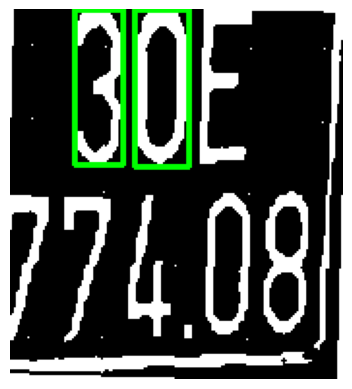


 BIỂN SỐ NHẬN DIỆN: 30


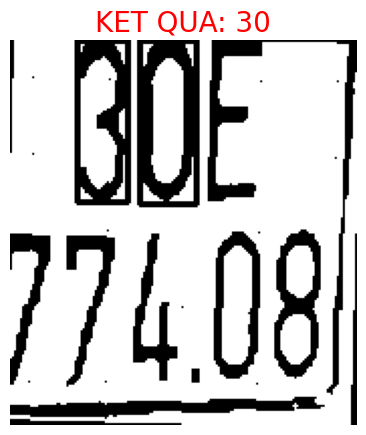

In [57]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import keras # Import Keras
# import joblib (Không cần nữa)

# --- 1. CẤU HÌNH ---
MODEL_PATH = 'bien_so_xe_cnn.keras'  # Đổi tên file model CNN của bạn
TARGET_SIZE = 28                

# --- 2. LOAD MODEL VÀ ĐỊNH NGHĨA NHÃN ---
print(" Đang load model CNN...")
try:
    # Load model Keras
    model = keras.models.load_model(MODEL_PATH)
    
    # QUAN TRỌNG: Danh sách này phải KHỚP THỨ TỰ với lúc bạn train (train_ds.class_names)
    # Nếu bộ dataset của bạn đầy đủ số và chữ, nó thường theo thứ tự này:
    class_names = ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9',
                   'A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'K', 'L', 
                   'M', 'N', 'P', 'R', 'S', 'T', 'U', 'V', 'X', 'Y', 'Z']
    print(" Load model thành công!")
except Exception as e:
    print(f" Lỗi load model: {e}")
    exit()

# --- 3. XỬ LÝ VÀ DỰ ĐOÁN ---
final_plate_str = ""
debug_images = []

# Giả sử hàm này trả về danh sách tọa độ (x, y, w, h)
rects = find_character_contours_heuristic(plate_img) 
sorted_rects = sort_rects_direct(rects)

for i, (x, y, w, h) in enumerate(sorted_rects):
    # Cắt và chuẩn hóa ảnh về kích thước TARGET_SIZE (28x28)
    char_img = process_char_standardized(plate_img, x, y, w, h, target_size=TARGET_SIZE)
    
    if char_img is None: continue
    
    # --- PHẦN KHÁC BIỆT CHÍNH SO VỚI RANDOM FOREST ---
    
    # 1. Chuẩn hóa về 0-1
    img_normalized = char_img.astype("float32") / 255.0
    
    # 2. Reshape cho CNN: (Batch_size, Height, Width, Channel)
    # RF dùng reshape(1, -1) để duỗi phẳng.
    # CNN cần giữ nguyên không gian 2D và thêm chiều kênh màu.
    # Input cần shape: (1, 28, 28, 1)
    input_data = np.expand_dims(img_normalized, axis=-1) # Thêm kênh màu -> (28, 28, 1)
    input_data = np.expand_dims(input_data, axis=0)      # Thêm batch -> (1, 28, 28, 1)
    
    # 3. Predict
    # Kết quả trả về là mảng xác suất (vd: [0.01, 0.9, 0.05...])
    predictions = model.predict(input_data, verbose=0)
    
    # 4. Lấy index có xác suất cao nhất
    pred_idx = np.argmax(predictions)
    confidence = np.max(predictions) # Độ tin cậy (nếu cần lọc ngưỡng)

    # 5. Map index sang ký tự
    if pred_idx < len(class_names):
        char_label = class_names[pred_idx]
    else:
        char_label = "?"

    # --------------------------------------------------

    final_plate_str += str(char_label)
    debug_images.append((char_img, char_label))

# --- 4. HIỂN THỊ KẾT QUẢ ---
print(f"\n BIỂN SỐ NHẬN DIỆN: {final_plate_str}")

# Vẽ lên ảnh gốc để show hàng
display_img = plate_img.copy()
for i, (x, y, w, h) in enumerate(sorted_rects):
    cv2.rectangle(display_img, (x, y), (x+w, y+h), (0, 255, 0), 2)
    # Viết chữ nhận diện được lên ảnh
    if i < len(debug_images):
        cv2.putText(display_img, debug_images[i][1], (x, y-5), 
                    cv2.FONT_HERSHEY_SIMPLEX, 0.8, (0, 255, 0), 2)

plt.figure(figsize=(10, 5))
plt.imshow(cv2.cvtColor(display_img, cv2.COLOR_BGR2RGB))
plt.title(f"KET QUA: {final_plate_str}", fontsize=20, color='red')
plt.axis('off')
plt.show()

In [58]:
# #!/usr/bin/env python3
# """
# corrected_confusion_plot.py

# Fixes the ValueError you saw when calling ConfusionMatrixDisplay.plot:
# "The number of FixedLocator locations (19)... does not match the number of labels (27)."

# Root cause:
# - The confusion matrix `cm` has shape (n, n) but `display_labels` you passed to ConfusionMatrixDisplay has a different length.
#   This happens when `unique_labels` is not the exact label list used to build `cm`.

# Fix:
# - Build an explicit `labels` list and pass it to confusion_matrix(...) so `cm` and `labels` are guaranteed to match.
# - Use a fresh axes (fig, ax = plt.subplots(...)) so there are no leftover tick locators.
# - Add sanity checks and helpful debug prints.

# Usage:
#   - Ensure y_test and y_pred are available (numpy arrays or lists).
#   - Run this script (or import and call plot_confusion(y_test, y_pred, ...)).

# """
# from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
# import matplotlib.pyplot as plt
# import numpy as np

# def plot_confusion(y_true, y_pred, title=None, figsize=(12,10), cmap='Blues', top_mis=10):
#     # Ensure numpy arrays
#     y_true = np.asarray(y_true)
#     y_pred = np.asarray(y_pred)

#     # 1) Build label list that includes every label that appears in either true or pred.
#     #    Using np.unique will sort; if you want to preserve appearance order use the commented alternative.
#     labels = np.unique(np.concatenate([y_true, y_pred]))
#     # Alternative to preserve order of appearance in y_true then y_pred:
#     # labels = list(dict.fromkeys(list(y_true) + list(y_pred)))

#     # 2) Compute confusion matrix using the explicit labels list
#     cm = confusion_matrix(y_true, y_pred, labels=labels)

#     # Debugging info to check shapes / lengths to avoid the ValueError
#     print("DEBUG: cm.shape:", cm.shape)
#     print("DEBUG: len(labels):", len(labels))
#     if cm.shape[0] != len(labels):
#         raise RuntimeError("Internal error: cm dimension doesn't match labels length after explicit labels passed to confusion_matrix()")

#     # 3) Plot on a fresh figure/axes (avoids FixedLocator mismatch if ax was reused)
#     fig, ax = plt.subplots(figsize=figsize)

#     disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
#     # ConfusionMatrixDisplay.plot will set ticks to np.arange(n_classes) internally,
#     # so since `labels` matches cm.shape this will no longer raise the FixedLocator error.
#     disp.plot(cmap=cmap, ax=ax, values_format='d', xticks_rotation=45)

#     # 4) Titles and labels
#     if title is None:
#         title = 'Confusion Matrix - Đánh giá độ chính xác mô hình nhận diện ký tự'
#     ax.set_title(title, fontsize=16, fontweight='bold', pad=20)
#     ax.set_xlabel('Nhãn dự đoán (Predicted Label)', fontsize=12)
#     ax.set_ylabel('Nhãn thực tế (True Label)', fontsize=12)

#     plt.tight_layout()
#     plt.show()

#     # 5) Analysis / metrics
#     total_samples = np.sum(cm)
#     correct = np.trace(cm)
#     incorrect = total_samples - correct
#     overall_acc = correct / total_samples if total_samples > 0 else 0.0

#     print("\n=== PHÂN TÍCH CHI TIẾT ===")
#     print(f"Tổng số mẫu test: {total_samples}")
#     print(f"Số mẫu dự đoán đúng: {correct}")
#     print(f"Số mẫu dự đoán sai: {incorrect}")
#     print(f"Độ chính xác tổng thể: {overall_acc * 100:.2f}%")

#     # 6) Misclassified pairs
#     misclassified = []
#     n_classes = cm.shape[0]
#     for i in range(n_classes):
#         for j in range(n_classes):
#             if i != j and cm[i, j] > 0:
#                 true_label = labels[i]
#                 pred_label = labels[j]
#                 count = cm[i, j]
#                 misclassified.append((count, true_label, pred_label))

#     misclassified.sort(reverse=True)
#     print("\nTop {} cặp ký tự hay bị nhầm lẫn:".format(top_mis))
#     for idx, (count, true_label, pred_label) in enumerate(misclassified[:top_mis], 1):
#         print(f"{idx}. '{true_label}' bị nhầm thành '{pred_label}': {count} lần")

#     # 7) Per-class accuracy
#     per_class_accuracy = []
#     for i, label in enumerate(labels):
#         total = np.sum(cm[i, :])  # total true samples of this label
#         correct = cm[i, i]
#         if total > 0:
#             acc = (correct / total) * 100.0
#         else:
#             acc = None
#         per_class_accuracy.append((label, acc, int(correct), int(total)))

#     # sort by accuracy ignoring None (put None at end)
#     per_class_accuracy_sorted = sorted(per_class_accuracy, key=lambda x: (100000 if x[1] is None else x[1]))

#     print("\nCác ký tự có độ chính xác THẤP NHẤT:")
#     for label, acc_val, correct, total in per_class_accuracy_sorted[:5]:
#         if acc_val is None:
#             print(f"  '{label}': no true samples ({correct}/{total})")
#         else:
#             print(f"  '{label}': {acc_val:.1f}% ({correct}/{total})")

#     print("\nCác ký tự có độ chính xác CAO NHẤT:")
#     for label, acc_val, correct, total in per_class_accuracy_sorted[-5:]:
#         if acc_val is None:
#             print(f"  '{label}': no true samples ({correct}/{total})")
#         else:
#             print(f"  '{label}': {acc_val:.1f}% ({correct}/{total})")

#     print("\n=== HOÀN THÀNH ĐÁNH GIÁ ===")

#     return {
#         "cm": cm,
#         "labels": labels,
#         "overall_accuracy": overall_acc,
#         "misclassified": misclassified,
#         "per_class_accuracy": per_class_accuracy
#     }

# # Example usage:
# res = plot_confusion(y_test, y_pred)
# # If you prefer seaborn heatmap instead of ConfusionMatrixDisplay, use:
# import seaborn as sns
# sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=unique_labels, yticklabels=unique_labels)

In [59]:
# # === ĐÁNH GIÁ KHẢ NĂNG CẮT BIỂN SỐ ===
# import os
# import glob
# from typing import List, Tuple, Dict
# import time

# def evaluate_plate_detection(image_folder: str, max_images: int = 200, show_failures: bool = True):
#     """
#     Đánh giá khả năng phát hiện và cắt biển số từ ảnh gốc.
    
#     Parameters:
#     -----------
#     image_folder : str
#         Đường dẫn đến folder chứa ảnh cần test (ví dụ: 'test/images' hoặc 'valid/images')
#     max_images : int
#         Số lượng ảnh tối đa để test (để tránh chạy quá lâu)
#     show_failures : bool
#         Có hiển thị các ảnh không cắt được biển số hay không
    
#     Returns:
#     --------
#     dict: Kết quả đánh giá bao gồm detection rate, thời gian xử lý, v.v.
#     """
    
#     print("="*70)
#     print("ĐÁNH GIÁ KHẢ NĂNG PHÁT HIỆN VÀ CẮT BIỂN SỐ")
#     print("="*70)
    
#     # 1. Tìm tất cả ảnh trong folder
#     image_extensions = ['*.jpg', '*.jpeg', '*.png', '*.JPG', '*.JPEG', '*.PNG']
#     all_images = []
    
#     for ext in image_extensions:
#         all_images.extend(glob.glob(os.path.join(image_folder, ext)))
    
#     if len(all_images) == 0:
#         print(f" CẢNH BÁO: Không tìm thấy ảnh nào trong folder '{image_folder}'")
#         print("Vui lòng kiểm tra lại đường dẫn hoặc tạo folder test/images với một số ảnh xe.")
#         return None
    
#     # Giới hạn số lượng ảnh test
#     test_images = all_images[:max_images]
#     total_images = len(test_images)
    
#     print(f"\n Folder test: {image_folder}")
#     print(f" Tổng số ảnh tìm thấy: {len(all_images)}")
#     print(f" Số ảnh sẽ test: {total_images}")
#     print("\n" + "-"*70)
    
#     # 2. Các biến thống kê
#     results = {
#         'total': total_images,
#         'detected': 0,
#         'failed': 0,
#         'failed_images': [],
#         'detection_times': [],
#         'plate_sizes': []
#     }
    
#     # 3. Xử lý từng ảnh
#     for idx, img_path in enumerate(test_images, 1):
#         filename = os.path.basename(img_path)
        
#         # Đọc ảnh
#         img_original = cv2.imread(img_path)
#         if img_original is None:
#             print(f" [{idx}/{total_images}] Không đọc được: {filename}")
#             results['failed'] += 1
#             results['failed_images'].append((filename, "Cannot read image"))
#             continue
        
#         # Đo thời gian xử lý
#         start_time = time.time()
        
#         try:
#             # Chuyển sang grayscale và binary
#             gray = grayimg(img_original)
#             binary = BinaryImg(gray.copy())
            
#             # Tìm contours
#             contours_found, _ = cv2.findContours(binary, cv2.RETR_TREE, cv2.CHAIN_APPROX_NONE)
            
#             # Tìm biển số
#             screenCnt_result, plate_detected = locate_license_plate(binary, contours_found)
            
#             detection_time = time.time() - start_time
#             results['detection_times'].append(detection_time)
            
#             # Kiểm tra kết quả
#             if plate_detected is not None and plate_detected.size > 0:
#                 # Thành công!
#                 results['detected'] += 1
#                 h, w = plate_detected.shape[:2]
#                 results['plate_sizes'].append((w, h))
                
#                 status = " DETECTED"
#                 detail = f"size={w}x{h}, time={detection_time*1000:.1f}ms"
#             else:
#                 # Thất bại
#                 results['failed'] += 1
#                 results['failed_images'].append((filename, "No plate found"))
#                 status = " FAILED"
#                 detail = f"time={detection_time*1000:.1f}ms"
                
#                 # Hiển thị ảnh thất bại nếu được yêu cầu
#                 if show_failures and results['failed'] <= 5:  # Chỉ show 5 ảnh đầu
#                     plt.figure(figsize=(8, 5))
#                     plt.imshow(cv2.cvtColor(img_original, cv2.COLOR_BGR2RGB))
#                     plt.title(f"FAILED: {filename}", fontsize=14, color='red')
#                     plt.axis('off')
#                     plt.show()
        
#         except Exception as e:
#             results['failed'] += 1
#             results['failed_images'].append((filename, str(e)))
#             status = " ERROR"
#             detail = f"Exception: {str(e)[:50]}"
        
#         # In progress mỗi 10 ảnh
#         if idx % 10 == 0 or idx == total_images:
#             print(f"[{idx}/{total_images}] {filename[:40]:40s} | {status} | {detail}")
    
#     # 4. Tính toán metrics
#     detection_rate = (results['detected'] / results['total'] * 100) if results['total'] > 0 else 0
#     avg_time = np.mean(results['detection_times']) if results['detection_times'] else 0
    
#     # 5. In kết quả tổng hợp
#     print("\n" + "="*70)
#     print("KẾT QUẢ ĐÁNH GIÁ")
#     print("="*70)
#     print(f"\n TỔNG QUAN:")
#     print(f"   • Tổng số ảnh test: {results['total']}")
#     print(f"   • Cắt được biển số: {results['detected']} ảnh")
#     print(f"   • Không cắt được: {results['failed']} ảnh")
#     print(f"\n TỶ LỆ PHÁT HIỆN (Detection Rate): {detection_rate:.2f}%")
#     print(f"\n THỜI GIAN XỬ LÝ:")
#     print(f"   • Trung bình: {avg_time*1000:.2f} ms/ảnh")
#     print(f"   • Tổng thời gian: {sum(results['detection_times']):.2f}s")
    
#     if results['plate_sizes']:
#         avg_width = np.mean([s[0] for s in results['plate_sizes']])
#         avg_height = np.mean([s[1] for s in results['plate_sizes']])
#         print(f"\n KÍCH THƯỚC BIỂN SỐ CẮT ĐƯỢC (trung bình):")
#         print(f"   • Rộng: {avg_width:.1f} px")
#         print(f"   • Cao: {avg_height:.1f} px")
#         print(f"   • Tỷ lệ W/H: {avg_width/avg_height:.2f}")
    
#     # 6. Danh sách ảnh thất bại
#     if results['failed_images']:
#         print(f"\n DANH SÁCH ẢNH KHÔNG CẮT ĐƯỢC ({len(results['failed_images'])} ảnh):")
#         for i, (fname, reason) in enumerate(results['failed_images'][:10], 1):
#             print(f"   {i}. {fname} - Lý do: {reason}")
#         if len(results['failed_images']) > 10:
#             print(f"   ... và {len(results['failed_images']) - 10} ảnh khác")
    
#     # 7. Đánh giá chất lượng
#     print(f"\n ĐÁNH GIÁ:")
#     if detection_rate >= 90:
#         rating = " XUẤT SẮC"
#         comment = "Hệ thống hoạt động rất tốt!"
#     elif detection_rate >= 75:
#         rating = " TỐT"
#         comment = "Chất lượng chấp nhận được, có thể cải thiện thêm."
#     elif detection_rate >= 50:
#         rating = " TRUNG BÌNH"
#         comment = "Cần điều chỉnh tham số hoặc cải thiện thuật toán."
#     else:
#         rating = " YẾU"
#         comment = "Cần xem xét lại phương pháp tiền xử lý và phát hiện biển số."
    
#     print(f"   {rating} - {comment}")
    
#     print("\n" + "="*70)
    
#     return results


# # === CHẠY ĐÁNH GIÁ ===
# # Thay đổi đường dẫn folder nếu cần
# TEST_FOLDER = "test/images"  # Hoặc "valid/images", "train/images", v.v.

# # Kiểm tra folder có tồn tại không
# if os.path.exists(TEST_FOLDER):
#     evaluation_results = evaluate_plate_detection(
#         image_folder=TEST_FOLDER,
#         max_images=999999,       # Chạy TOÀN BỘ ảnh trong folder (không giới hạn)
#         show_failures=True       # Hiển thị 5 ảnh đầu tiên không cắt được
#     )
# else:
#     print(f" Folder '{TEST_FOLDER}' không tồn tại!")
#     print("Vui lòng tạo folder hoặc thay đổi TEST_FOLDER thành đường dẫn hợp lệ.")
#     print("\nVí dụ các đường dẫn có thể dùng:")
#     print("  - 'test/images'")
#     print("  - 'valid/images'")
#     print("  - 'train/images'")